# CHAPTER 3 深度神经网络

在第二章中，我们介绍了浅层神经网络的前向传播过程，并引入了**折叠空间**的核心直觉：激活函数 ReLU 赋予神经网络"弯曲"和"折叠"空间的能力，而神经元数量决定了能折叠多少次。

这一章我们将沿着"折叠"这条线索继续深入。第二章的策略是**横向扩展**——在同一层中增加神经元数量。本章我们探讨另一种策略：**纵向扩展**——堆叠多个隐藏层，构建**深度神经网络**。

> 本章的核心参考是 *Understanding Deep Learning*（UDL）第 4 章。

## 3.1 为什么要堆叠层？

回顾第二章，单隐层 ReLU 网络可以理解为：用 $D$ 个隐藏神经元，在输入空间上制造 $D$ 个"折痕"，形成最多 $D+1$ 个线性区域。

但这种方式有一个隐含的低效之处：**每个折痕只能作用于原始输入空间**。如果我们先对输入做一次变换，再在这个**变换后的空间**上施加折痕呢？

这就是深度网络的核心思想：**通过堆叠多个隐藏层，让每一次"折叠"都建立在前一次折叠的结果之上**。

为了建立直觉，我们先考虑一个最简单的深度构造：把**两个**浅层网络首尾相连——第一个网络的输出直接作为第二个网络的输入。

## 3.2 组合两个浅层网络

考虑以下构造（对应 UDL 图 4.1）。两个网络各有 3 个 ReLU 隐藏单元，各自产生 3 段交替斜率的线性区域。

<img src="../attachment/图3-1.jpg" width="700" style="display: block; margin: 0 auto;" >

**第一个网络** $f_1: x \rightarrow y$：

$$
\begin{aligned}
h_1 &= \text{ReLU}[\theta_{10} + \theta_{11} x] \\
h_2 &= \text{ReLU}[\theta_{20} + \theta_{21} x] \\
h_3 &= \text{ReLU}[\theta_{30} + \theta_{31} x] \\
y   &= \phi_0 + \phi_1 h_1 + \phi_2 h_2 + \phi_3 h_3
\end{aligned}
$$

**第二个网络** $f_2: y \rightarrow y'$：

$$
\begin{aligned}
h'_1 &= \text{ReLU}[\theta'_{10} + \theta'_{11} y] \\
h'_2 &= \text{ReLU}[\theta'_{20} + \theta'_{21} y] \\
h'_3 &= \text{ReLU}[\theta'_{30} + \theta'_{31} y] \\
y'   &= \phi'_0 + \phi'_1 h'_1 + \phi'_2 h'_2 + \phi'_3 h'_3
\end{aligned}
$$

这里注意，y并没有经过激活函数ReLu的处理，是直接作为输入传递到下一个网络当中的，这点很重要。

整体映射为 $y' = f_2(f_1(x))$。

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def relu(z):
    return np.maximum(0, z)

class ShallowNet1:
    def __init__(self):
        self.theta_0 = np.array([1.0, 1/3, -1/3])
        self.theta_1 = np.array([1.0, 1.0,  1.0])
        self.phi_0   = -1.0
        self.phi     = np.array([3.0, -6.0, 6.0])

    def forward(self, x):
        h1 = relu(self.theta_0[0] + self.theta_1[0] * x)
        h2 = relu(self.theta_0[1] + self.theta_1[1] * x)
        h3 = relu(self.theta_0[2] + self.theta_1[2] * x)
        y  = self.phi_0 + self.phi[0]*h1 + self.phi[1]*h2 + self.phi[2]*h3
        return y, (h1, h2, h3)

net1 = ShallowNet1()

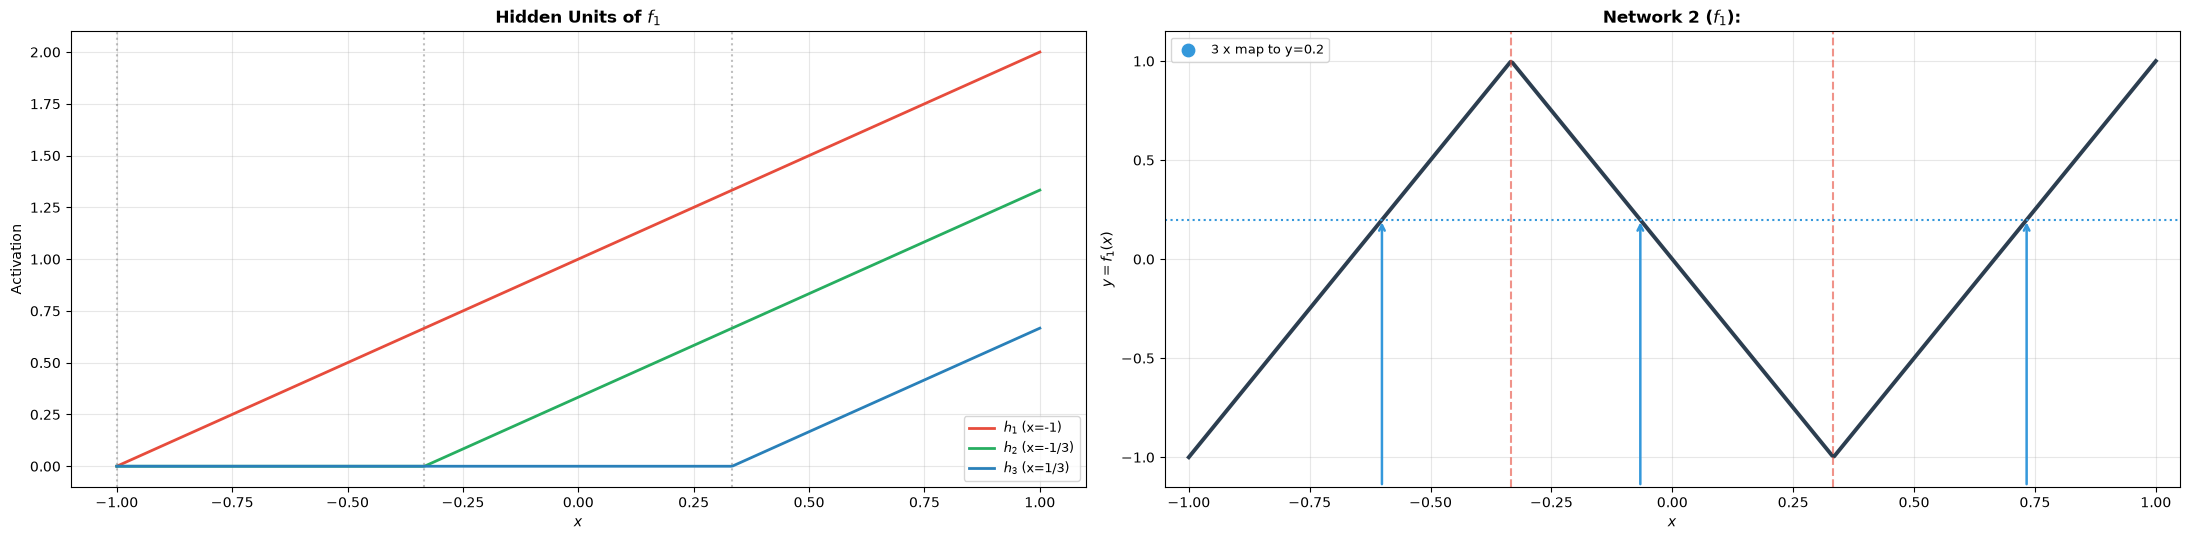

In [8]:
# 可视化第一个网络
x_dense = np.linspace(-1, 1, 500)
y_dense, hs_dense = net1.forward(x_dense)

fig, axes = plt.subplots(1, 2, figsize=(22, 5.5))

# Panel A: 隐藏单元激活
ax = axes[0]
colors_h = ['#E74C3C', '#27AE60', '#2980B9']
for i in range(3):
    ax.plot(x_dense, hs_dense[i], color=colors_h[i], linewidth=2,
            label=[r'$h_1$ (x=-1)', r'$h_2$ (x=-1/3)', r'$h_3$ (x=1/3)'][i])
for jx in [-1, -1/3, 1/3]:
    ax.axvline(x=jx, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('$x$'); ax.set_ylabel('Activation')
ax.set_title('Hidden Units of $f_1$', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlim(-1.1, 1.1)

# Panel B: f1 输出函数
ax = axes[1]
ax.plot(x_dense, y_dense, '#2C3E50', linewidth=2.8)
for jx in [-1/3, 1/3]:
    ax.axvline(x=jx, color='#E74C3C', linestyle='--', alpha=0.6)

# 展示折叠: 3个不同的x映射到同一个y
y_demo = 0.2
for rx in [np.linspace(-1, -1/3, 500), np.linspace(-1/3, 1/3, 500), np.linspace(1/3, 1, 500)]:
    yr, _ = net1.forward(rx)
    xm = rx[np.argmin(np.abs(yr - y_demo))]
    ax.annotate('', xy=(xm, y_demo), xytext=(xm, -1.15),
                arrowprops=dict(arrowstyle='->', color='#3498DB', lw=1.8))
ax.axhline(y=y_demo, color='#3498DB', linestyle=':', linewidth=1.5)
ax.scatter([],[],c='#3498DB',s=80,label=f'3 x map to y={y_demo}')
ax.set_xlabel('$x$'); ax.set_ylabel('$y = f_1(x)$')
ax.set_title('Network 2 ($f_1$):', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.15, 1.15)

plt.tight_layout(); plt.show()

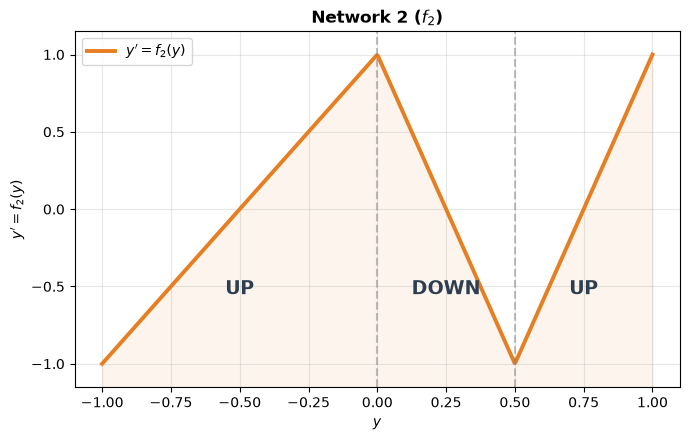

In [9]:
class ShallowNet2:
    def __init__(self):
        self.theta_0 = np.array([1.0, 0.0, -0.5])
        self.theta_1 = np.array([1.0, 1.0,  1.0])
        self.phi_0   = -1.0
        self.phi     = np.array([2.0, -6.0, 8.0])

    def forward(self, y):
        h1 = relu(self.theta_0[0] + self.theta_1[0] * y)
        h2 = relu(self.theta_0[1] + self.theta_1[1] * y)
        h3 = relu(self.theta_0[2] + self.theta_1[2] * y)
        yp = self.phi_0 + self.phi[0]*h1 + self.phi[1]*h2 + self.phi[2]*h3
        return yp, (h1, h2, h3)

net2 = ShallowNet2()
# 可视化 f2
y_dense = np.linspace(-1, 1, 500)
yp_dense, _ = net2.forward(y_dense)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(y_dense, yp_dense, '#E67E22', linewidth=2.8, label=r"$y' = f_2(y)$")
for yj in [0, 0.5]:
    ax.axvline(x=yj, color='gray', linestyle='--', alpha=0.5)
ax.fill_between(y_dense, yp_dense, -1.15, alpha=0.08, color='#E67E22')
for ym, d in [(-0.5, 'UP'), (0.25, 'DOWN'), (0.75, 'UP')]:
    ax.text(ym, -0.55, d, fontsize=14, ha='center', color='#2C3E50', fontweight='bold')
ax.set_xlabel('$y$'); ax.set_ylabel("$y' = f_2(y)$")
ax.set_title('Network 2 ($f_2$)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.15, 1.15)
plt.tight_layout(); plt.show()

下面我们将两个网络组合，看看会出现什么样的结果？

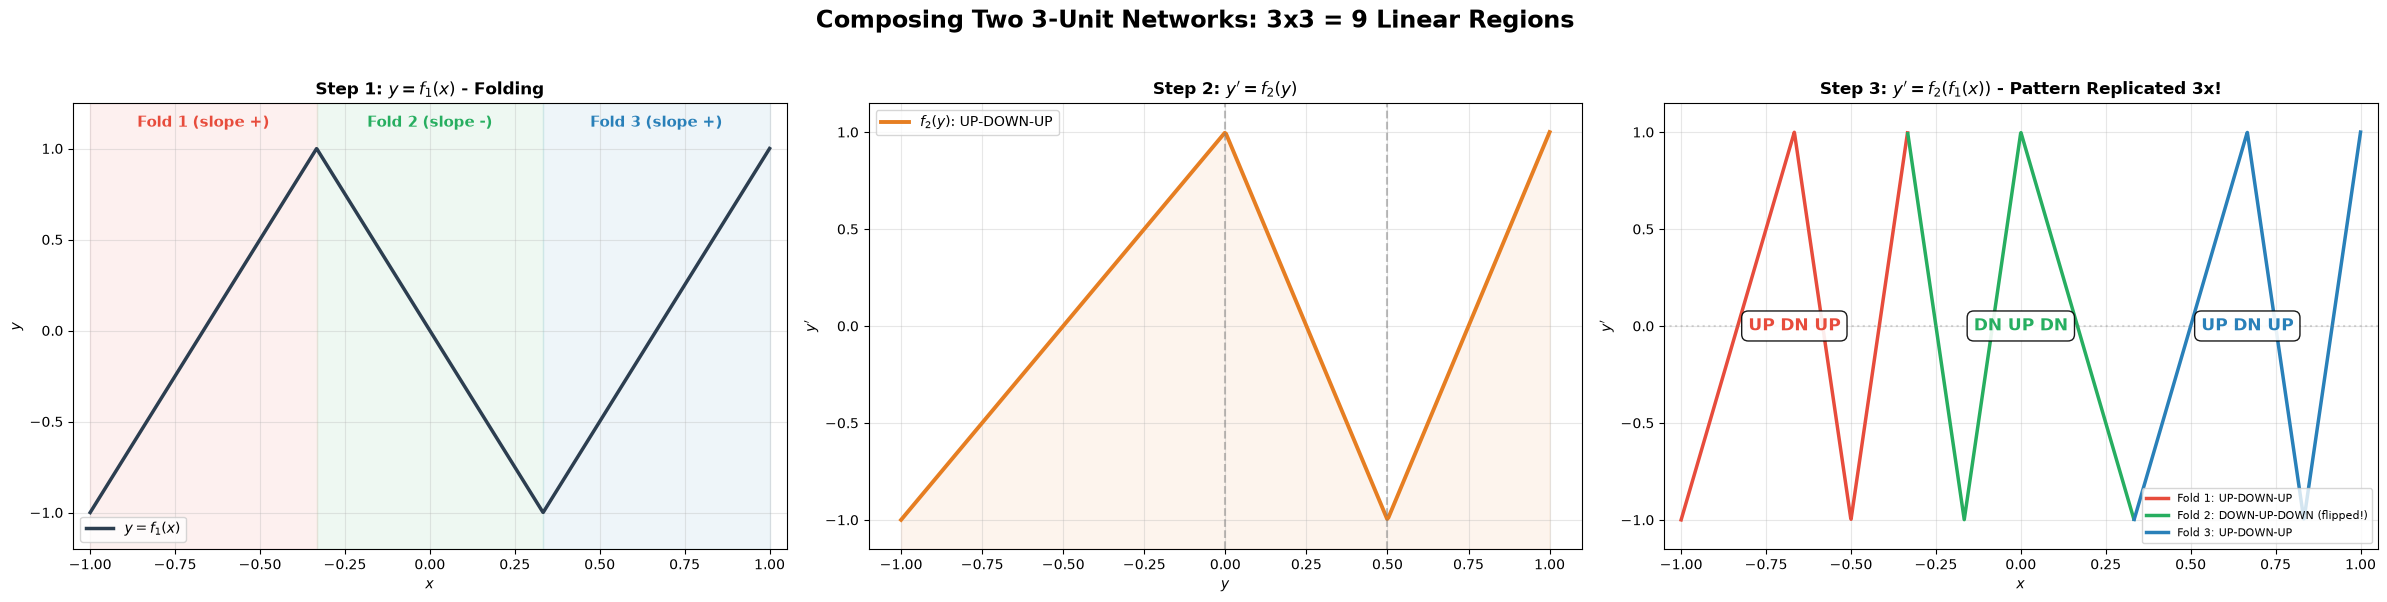

In [10]:
x_dense = np.linspace(-1, 1, 2000)
y_inter, _ = net1.forward(x_dense)
y_final, _ = net2.forward(y_inter)

fig, axes = plt.subplots(1, 3, figsize=(24, 5.8))

fold_colors = ['#E74C3C', '#27AE60', '#2980B9']
fold_bounds = [(-1, -1/3), (-1/3, 1/3), (1/3, 1)]

# Panel A: f1 output
ax = axes[0]
ax.plot(x_dense, y_inter, '#2C3E50', linewidth=2.5, label=r'$y = f_1(x)$')
for (xs,xe),c,lbl in zip(fold_bounds,fold_colors,
    ['Fold 1 (slope +)', 'Fold 2 (slope -)', 'Fold 3 (slope +)']):
    ax.axvspan(xs, xe, alpha=0.08, color=c)
    ax.text((xs+xe)/2, 1.12, lbl, fontsize=11, ha='center', fontweight='bold', color=c)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('Step 1: $y = f_1(x)$ - Folding', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.2, 1.25)

# Panel B: f2 on y
ax = axes[1]
yd = np.linspace(-1, 1, 500); ypd, _ = net2.forward(yd)
ax.plot(yd, ypd, '#E67E22', linewidth=2.8, label=r"$f_2(y)$: UP-DOWN-UP")
ax.fill_between(yd, ypd, -1.15, alpha=0.08, color='#E67E22')
for yj in [0, 0.5]:
    ax.axvline(x=yj, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('$y$'); ax.set_ylabel("$y'$")
ax.set_title('Step 2: $y\' = f_2(y)$', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.15, 1.15)

# Panel C: composition
ax = axes[2]
patterns = ['Fold 1: UP-DOWN-UP', 'Fold 2: DOWN-UP-DOWN (flipped!)', 'Fold 3: UP-DOWN-UP']
arrows = ['UP DN UP', 'DN UP DN', 'UP DN UP']
for (xs,xe),c,lbl,arr in zip(fold_bounds,fold_colors,patterns,arrows):
    mask = (x_dense >= xs) & (x_dense <= xe)
    ax.plot(x_dense[mask], y_final[mask], color=c, linewidth=2.5, label=lbl)
    ax.annotate(arr, xy=((xs+xe)/2, 0), fontsize=12, ha='center', va='center',
                color=c, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9))
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.3)
ax.set_xlabel('$x$'); ax.set_ylabel("$y'$")
ax.set_title('Step 3: $y\'=f_2(f_1(x))$ - Pattern Replicated 3x!', fontweight='bold')
ax.legend(fontsize=8, loc='lower right'); ax.grid(True, alpha=0.3)
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.15, 1.15)

fig.suptitle('Composing Two 3-Unit Networks: 3x3 = 9 Linear Regions',
             fontsize=17, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()


我们用6个隐藏的神经元，最终创造出了9个线性区域。在我们上一章的理论中，一个单隐藏层网络含有 $D$ 个隐藏神经元，那么它最多能创建 $D + 1$ 个线性区域。显然，通过叠加神经网络的隐藏层，我们可以用更少的参数，去构造更复杂的网络。下面我们就来进一步解释为什么会出现这样的结果。

## 3.3 如何理解组合浅层网络——复合函数的视角

在UDL书中，作者给出两个理解角度，但是我们本质上可以从复合函数的角度出发来理解。

我们抛开原来前向传播的思维，先将两个神经网络分别计算出来，变成两个独立的函数。如下图b、c所示。

<img src="../attachment/图3-2.jpg" width="700" style="display: block; margin: 0 auto;" >

我们看到第一个网络被分割成了三段线性区域，第一段线性区域从-1到0的范围被映射到-1到1（即第二个网络的输入空间）当中。实际上就是将网络一的每一段线性区域和网络二做复合运算，输出成新的网络。我们也就自然看到在输出网络中，网络二的模式在网络一划分好的线性区域中，经过不同区域斜率的翻转处理后，重复地出现了三次。（如下图所示）

<img src="../attachment/图3-3.jpg" width="700" style="display: block; margin: 0 auto;" >

但是请你注意，不论是书中给的例子，还是我的代码中的例子都是经过参数设计的，目的就是让你理解这种“模式重复”的巧妙之处，实际上网络曲线不可能每次都出现这种正负交替形式，而且第一个网络的输出还恰好是第二个网络的输入的情况。

这样我们也就直观的感受到了组合浅层神经网络的优势所在。你是否还记得我们刚刚提到的设计组合网络的小心思？第一个的网络输出不经过激活函数处理就直接作为下一个网络的输入传递下去。其实这是从组合浅层网络到搭建深度神经网路的一种过渡手段。下面我们就正式进入深度神经网络了

## 3.4 构建深度神经网络

<img src="../attachment/图3-4.jpg" width="700" style="display: block; margin: 0 auto;" >

我们构建如上含有两个隐藏层的深度神经网络。我们可以将其简单地分成几个步骤：

1. 最先开始从输入层到第一层隐藏单元，首先构造出了三种不同斜率、偏置的线性单元。经过ReLU处理后成为 $h_1$、$h_2$、$h_3$ 输出单元。

$$
\begin{aligned}
h_1 &= a[\theta_{10} + \theta_{11} x] \\
h_2 &= a[\theta_{20} + \theta_{21} x] \\
h_3 &= a[\theta_{30} + \theta_{31} x]
\end{aligned}
$$

2. 再从 $h_1$、$h_2$、$h_3$ 开始到下一层的隐藏层的激活前阶段，输出单元分别经过三次线性组合，构建出三种不同的线性网络，分别作为 $h'_1$、$h'_2$、$h'_3$ 的输入，传递到下一层当中：

$$
\begin{aligned}
h'_1 &= a[\psi_{10} + \psi_{11} h_1 + \psi_{12} h_2 + \psi_{13} h_3] \\
h'_2 &= a[\psi_{20} + \psi_{21} h_1 + \psi_{22} h_2 + \psi_{23} h_3] \\
h'_3 &= a[\psi_{30} + \psi_{31} h_1 + \psi_{32} h_2 + \psi_{33} h_3]
\end{aligned}
$$

<img src="../attachment/图3-5.jpg" width="700" style="display: block; margin: 0 auto;" >

3. 线性网络经过第二层的激活函数处理，增加了新的折叠点位。

<img src="../attachment/图3-6.jpg" width="700" style="display: block; margin: 0 auto;" >

4. 三张线性网络再次经过线性组合，输出最后的网络。

$$
y' = \phi'_0 + \phi'_1 h'_1 + \phi'_2 h'_2 + \phi'_3 h'_3
$$

<img src="../attachment/图3-7.jpg" width="700" style="display: block; margin: 0 auto;" >

经过上面示意的流程以后，我们对深度网络的构建有了更加直观的理解。深层网络在向前传播的过程中，无非就干了三件事: 变换、裁剪（折叠）、最后组合。

> 输入和权重矩阵的内积是在做线性变换，生成不同的模式，再将不同的模式利用ReLU折叠空间，最后利用向量乘法做线性组合，不同的模式被组合在一起形成新的模式，然后循环往复，生成更加复杂的模式。

这种模式构建的方式与单隐藏层网络不同，这种深度网络的模式生成数量是呈指数级增长的。

## 3.5 深度网络的矩阵形式

基于 UDL 第 4.4 节，我们可以用矩阵记号将上述两层网络写成更紧凑的形式。

第一层：

$$
\begin{bmatrix} h_1 \\ h_2 \\ h_3 \end{bmatrix} = a\!\left[\begin{bmatrix} \theta_{10} \\ \theta_{20} \\ \theta_{30} \end{bmatrix} + \begin{bmatrix} \theta_{11} \\ \theta_{21} \\ \theta_{31} \end{bmatrix} x\right]
$$

第二层：

$$
\begin{bmatrix} h'_1 \\ h'_2 \\ h'_3 \end{bmatrix} = a\!\left[\begin{bmatrix} \psi_{10} \\ \psi_{20} \\ \psi_{30} \end{bmatrix} + \begin{bmatrix} \psi_{11} & \psi_{12} & \psi_{13} \\ \psi_{21} & \psi_{22} & \psi_{23} \\ \psi_{31} & \psi_{32} & \psi_{33} \end{bmatrix} \begin{bmatrix} h_1 \\ h_2 \\ h_3 \end{bmatrix}\right]
$$

输出层：

$$
y' = \phi'_0 + \begin{bmatrix} \phi'_1 & \phi'_2 & \phi'_3 \end{bmatrix} \begin{bmatrix} h'_1 \\ h'_2 \\ h'_3 \end{bmatrix}
$$

---

上面的例子是 $D_i=1, D_o=1, D_1=D_2=3$ 的特例。引入统一记号后（遵循 UDL 第 4.4.1 节），可以写出适用于**任意输入输出维度**的通用形式：

- $\mathbf{h}_k$：第 $k$ 层隐藏单元向量（维度 $D_k \times 1$）
- $\boldsymbol{\beta}_{k-1}$：馈入第 $k$ 层的偏置向量（维度 $D_k \times 1$）
- $\boldsymbol{\Omega}_{k-1}$：第 $k-1$ 层到第 $k$ 层的权重矩阵（维度 $D_k \times D_{k-1}$）
- $a[\cdot]$：逐元素应用激活函数

则任意深度的前馈网络可以统一写为（UDL 方程 4.15）：

$$
\boxed{\begin{aligned}
\mathbf{h}_1 &= a\!\left[\boldsymbol{\beta}_0 + \boldsymbol{\Omega}_0 \mathbf{x}\right] \\
\mathbf{h}_2 &= a\!\left[\boldsymbol{\beta}_1 + \boldsymbol{\Omega}_1 \mathbf{h}_1\right] \\
\mathbf{h}_3 &= a\!\left[\boldsymbol{\beta}_2 + \boldsymbol{\Omega}_2 \mathbf{h}_2\right] \\
&\;\;\vdots \\
\mathbf{h}_K &= a\!\left[\boldsymbol{\beta}_{K-1} + \boldsymbol{\Omega}_{K-1} \mathbf{h}_{K-1}\right] \\
\mathbf{y} &= \boldsymbol{\beta}_K + \boldsymbol{\Omega}_K \mathbf{h}_K
\end{aligned}}
$$

或者展开为单一嵌套表达式（UDL 方程 4.16）：

$$
\mathbf{y} = \boldsymbol{\beta}_K + \boldsymbol{\Omega}_K\, a\!\left[\boldsymbol{\beta}_{K-1} + \boldsymbol{\Omega}_{K-1}\, a\!\left[\cdots\, a\!\left[\boldsymbol{\beta}_1 + \boldsymbol{\Omega}_1\, a\!\left[\boldsymbol{\beta}_0 + \boldsymbol{\Omega}_0\mathbf{x}\right]\right]\cdots\right]\right]
$$

其中网络的全体参数 $\phi = \{\boldsymbol{\beta}_k, \boldsymbol{\Omega}_k\}_{k=0}^{K}$ 包含了所有权重矩阵和偏置向量。

> **注意**：这套矩阵记法是**通用的**，不限于单输入单输出。$\mathbf{x}$ 可以是任意 $D_i$ 维向量，$\mathbf{y}$ 可以是任意 $D_o$ 维向量，各隐藏层宽度 $D_k$ 也可以不同。

## 3.6 区分**组合网络**和**全连接深度网络**

在这一章中，我们从组合浅层网络谈起，过渡到深度网络。我们发现这两种网络带给我们的感觉是不一样的。这其实来自于权重矩阵的不同：

组合两个浅层网络得到的权重矩阵 $\boldsymbol{\Omega}_1$ 是**秩为 1** 的，而真正的两层深度网络中 $\boldsymbol{\Omega}_1$ 可以是**秩为 3** 的。这一节我们从数学推导出发，彻底厘清这个差异的根源，并解释它与"模式复制"现象之间的内在联系。

### 3.5.2 前向传播可视化：追踪模式复制的每一步

上面的推导解释了秩-1 约束是模式复制的数学根源。下面我们沿着组合网络的前向传播流程，**一步一步地**追踪数据从输入 $x$ 到最终输出 $y'$ 的完整路径，让"为什么 $f_2$ 的模式被复制到 $f_1$ 的每个折叠区域中"这个问题变得一目了然。

核心逻辑只有一句话：**$f_1$ 末尾把 $h_1,h_2,h_3$ 压缩成一个标量 $y$，导致 $f_2$ 的每个隐藏单元只能"看见" $y$——同一个 $y$ 值出现多少次，$f_2$ 的操作就被重复多少次。**

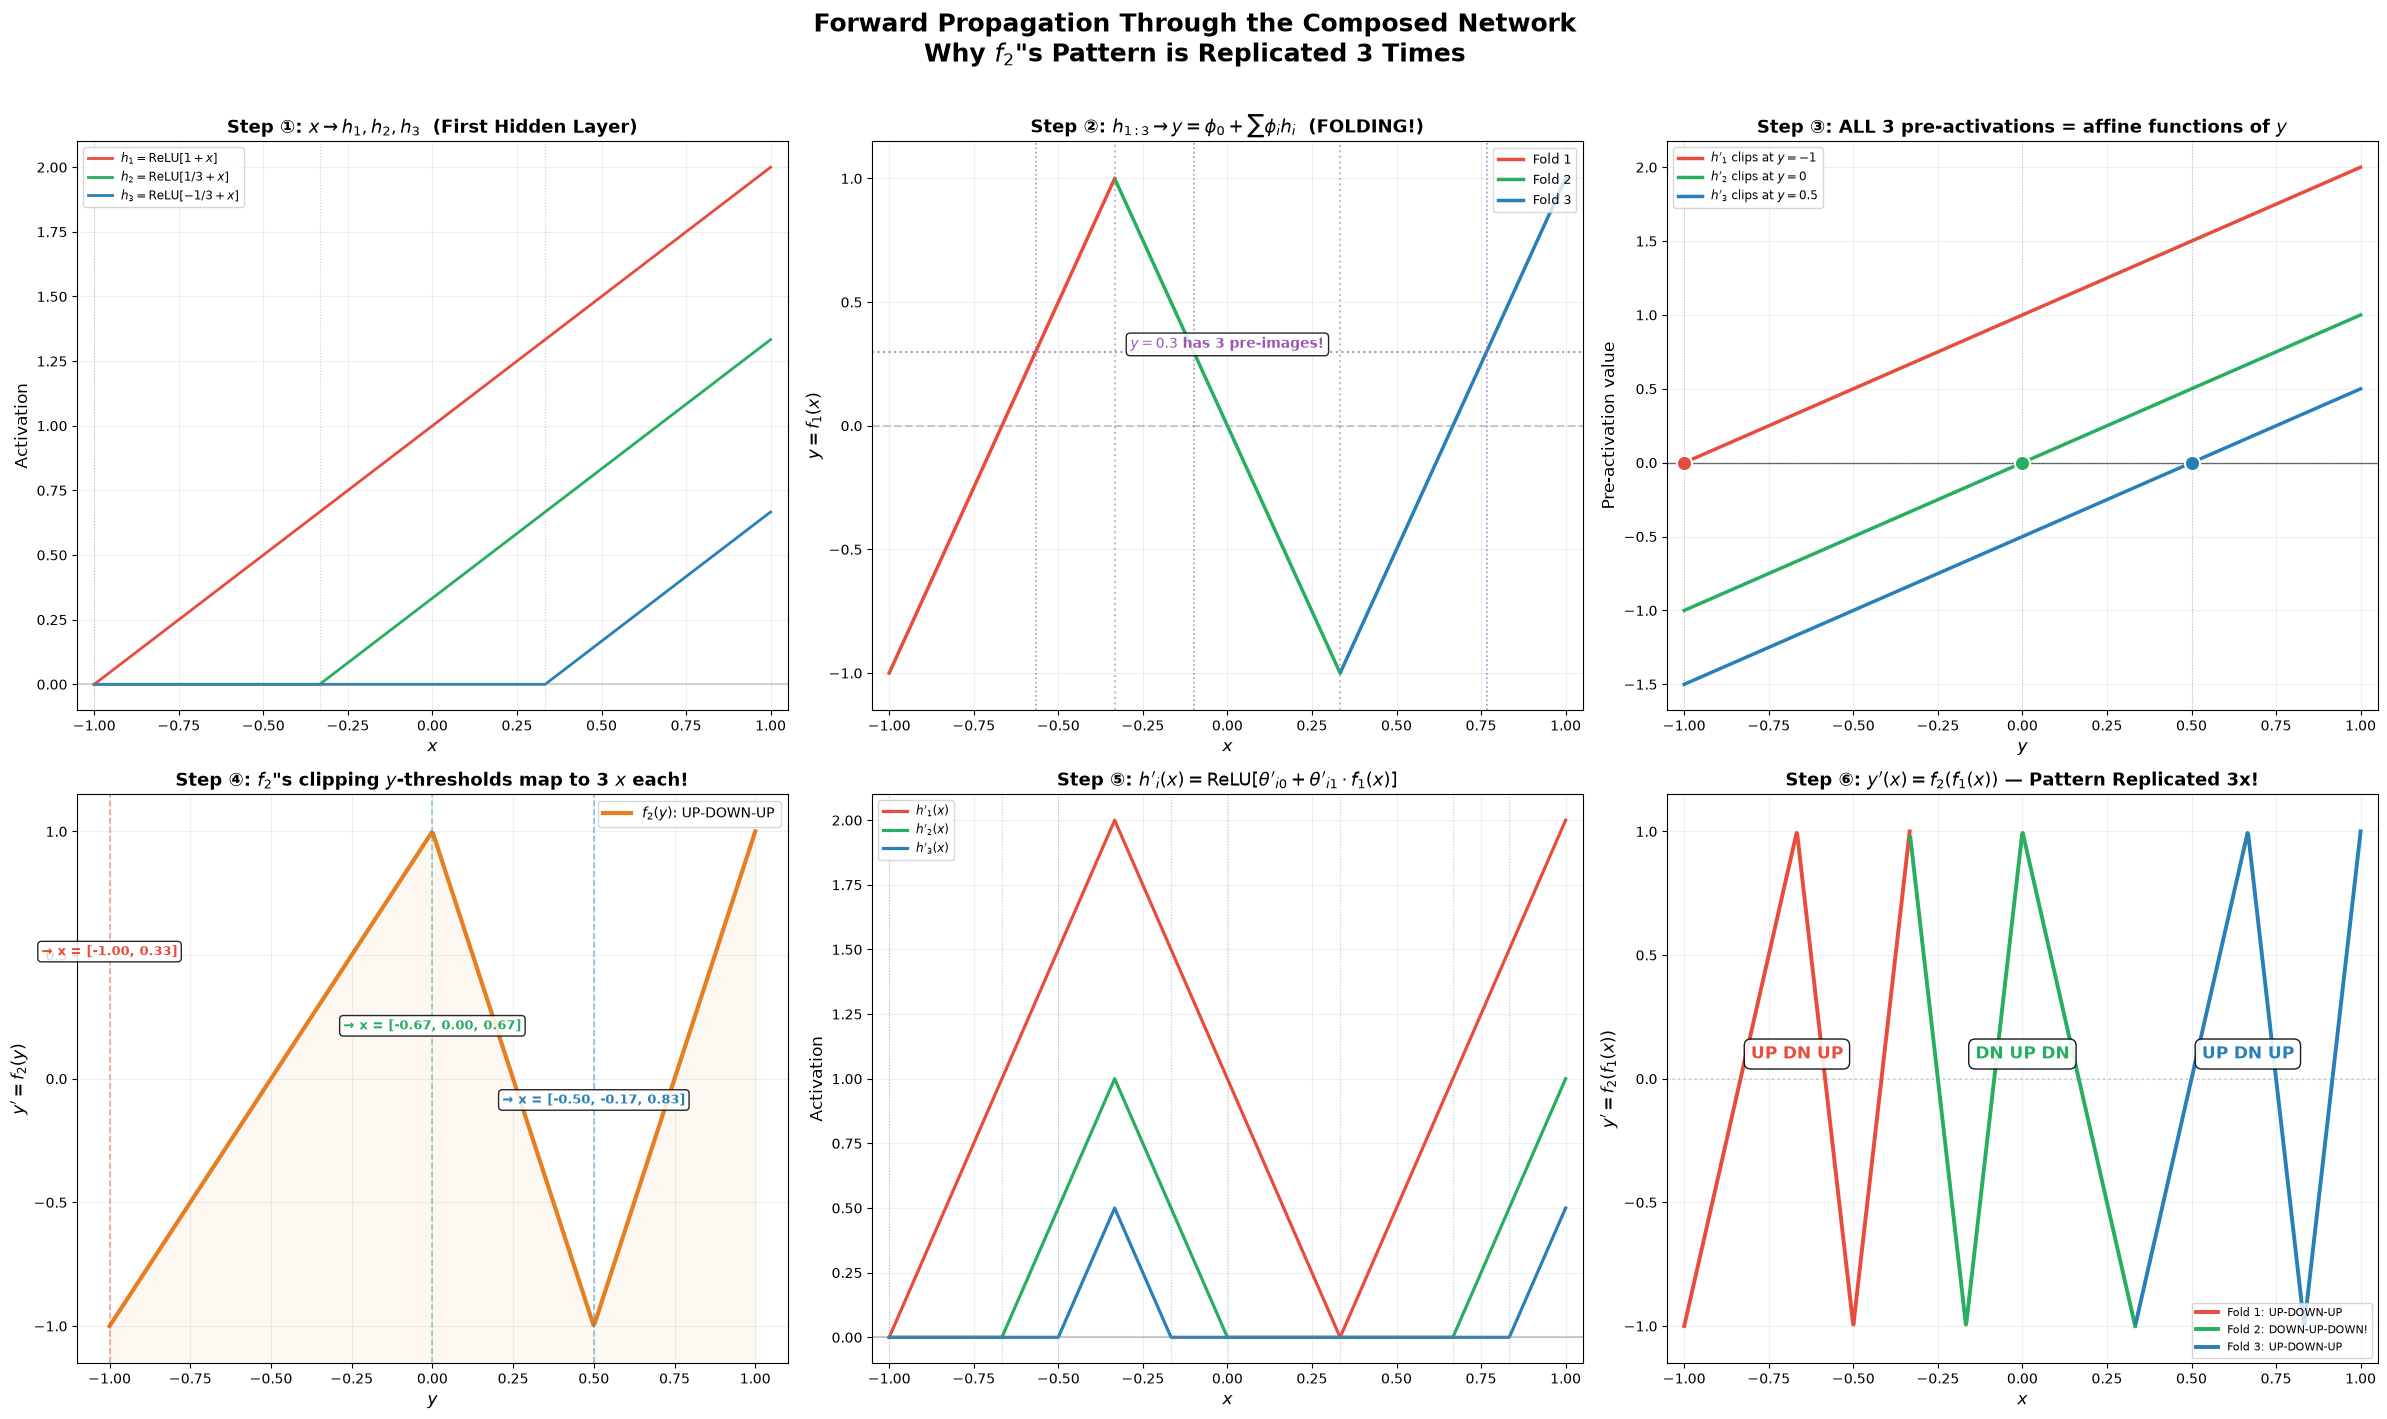

核心洞察: 为什么 f2 的模式被复制到 f1 的每个折叠区域?

1. f1 末尾把 h1,h2,h3 压缩成一个标量 y = phi0 + sum(phi_i * h_i)
   → 3维信息 -> 1维信息 (信息瓶颈!)

2. f2 的三个预激活 pre_i = theta'_i0 + theta'_i1 * y
   全部是 y 的仿射函数——它们只能看见 y 这一个数字

3. y = f1(x) 是一个折叠函数 (非单射):
   同一个 y 值对应 2~3 个不同的 x 位置

4. 因此, 每个 pre_i = 0 的裁剪事件在 y-空间中只发生一次,
   但在 x-空间中同时发生在所有映射到该 y 的 x 位置上
   h'1 在 y=-1.0 处裁剪 -> x = [np.float64(-1.0), np.float64(0.333)]
   h'2 在 y= 0.0 处裁剪 -> x = [np.float64(-0.666), np.float64(0.001), np.float64(0.666)]
   h'3 在 y= 0.5 处裁剪 -> x = [np.float64(-0.5), np.float64(-0.166), np.float64(0.833)]

5. f2 的 UP-DOWN-UP 模式就这样在 f1 的每个折叠区域内
被完整地复印了一次——这就是模式复制的本质!


In [11]:
# ============================================================
# 前向传播可视化: 逐步追踪组合网络中的模式复制
# ============================================================

x_dense = np.linspace(-1, 1, 1000)
y_dense, (h1, h2, h3) = net1.forward(x_dense)
yp_dense, (hp1, hp2, hp3) = net2.forward(y_dense)

# 网络二的预激活 (都是 y 的仿射函数!)
pre1 = net2.theta_0[0] + net2.theta_1[0] * y_dense
pre2 = net2.theta_0[1] + net2.theta_1[1] * y_dense
pre3 = net2.theta_0[2] + net2.theta_1[2] * y_dense

# 裁剪阈值 (pre_i = 0 对应的 y 值)
y_clip = np.array([-net2.theta_0[i]/net2.theta_1[i] for i in range(3)])
clip_names = [r"$h'_1$ clips at $y=-1$",
              r"$h'_2$ clips at $y=0$",
              r"$h'_3$ clips at $y=0.5$"]
clip_colors = ['#E74C3C', '#27AE60', '#2980B9']

# 找每个裁剪 y 值对应的 x 位置 (每个 fold 一个)
clip_x_all = []
for yc in y_clip:
    x_at_yc = []
    for rx in [np.linspace(-1, -1/3, 500),
               np.linspace(-1/3, 1/3, 500),
               np.linspace(1/3, 1, 500)]:
        yr, _ = net1.forward(rx)
        idx = np.argmin(np.abs(yr - yc))
        if abs(yr[idx] - yc) < 0.02:
            x_at_yc.append(rx[idx])
    clip_x_all.append(sorted(set(np.round(x_at_yc, 3))))

fold_colors = ['#E74C3C', '#27AE60', '#2980B9']
fold_bounds = [(-1, -1/3), (-1/3, 1/3), (1/3, 1)]
fold_labels = ['Fold 1', 'Fold 2', 'Fold 3']

# ============================================================
# 大图: 2x3 面板, 追踪完整的前向传播流程
# ============================================================
fig = plt.figure(figsize=(24, 14))

# ---- 行1 面板1: 步骤① x -> h1,h2,h3 (第一隐藏层) ----
ax = plt.subplot(2, 3, 1)
h_colors = ['#E74C3C', '#27AE60', '#2980B9']
for i, (h, c, lbl) in enumerate(zip([h1, h2, h3], h_colors,
    [r'$h_1 = \mathrm{ReLU}[1 + x]$',
     r'$h_2 = \mathrm{ReLU}[1/3 + x]$',
     r'$h_3 = \mathrm{ReLU}[-1/3 + x]$'])):
    ax.plot(x_dense, h, color=c, linewidth=2, label=lbl)
for jx in [-1, -1/3, 1/3]:
    ax.axvline(x=jx, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('Activation', fontsize=12)
ax.set_title(r'Step ①: $x \rightarrow h_1, h_2, h_3$  (First Hidden Layer)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8.5, loc='upper left')
ax.set_xlim(-1.05, 1.05); ax.grid(True, alpha=0.2)

# ---- 行1 面板2: 步骤② h1,h2,h3 -> y = f1(x) (THE BOTTLENECK!) ----
ax = plt.subplot(2, 3, 2)
for (xs, xe), c, lbl in zip(fold_bounds, fold_colors, fold_labels):
    mask = (x_dense >= xs) & (x_dense <= xe)
    ax.plot(x_dense[mask], y_dense[mask], color=c, linewidth=2.5, label=lbl)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
for jx in [-1/3, 1/3]:
    ax.axvline(x=jx, color='gray', linestyle=':', alpha=0.5)
# 标注: y 是关于 x 的非单射函数
y_demo = 0.3
for rx in [np.linspace(-1, -1/3, 500), np.linspace(-1/3, 1/3, 500), np.linspace(1/3, 1, 500)]:
    yr, _ = net1.forward(rx)
    xm = rx[np.argmin(np.abs(yr - y_demo))]
    ax.axvline(x=xm, color='#9B59B6', linestyle=':', alpha=0.7, linewidth=1.2)
ax.axhline(y=y_demo, color='#9B59B6', linestyle=':', alpha=0.7, linewidth=1.5)
ax.annotate(r'$y=' + str(y_demo) + r'$ has 3 pre-images!',
            xy=(0, y_demo), fontsize=10, color='#9B59B6', fontweight='bold',
            ha='center', va='bottom',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$y = f_1(x)$', fontsize=12)
ax.set_title(r'Step ②: $h_{1:3} \rightarrow y = \phi_0 + \sum\phi_i h_i$  (FOLDING!)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.15, 1.15); ax.grid(True, alpha=0.2)

# ---- 行1 面板3: 步骤③ y -> pre1,pre2,pre3 (三个都是 y 的仿射函数!) ----
ax = plt.subplot(2, 3, 3)
y_axis = np.linspace(-1, 1, 300)
for i, (c, lbl, yc) in enumerate(zip(clip_colors, clip_names, y_clip)):
    pre_line = net2.theta_0[i] + net2.theta_1[i] * y_axis
    ax.plot(y_axis, pre_line, color=c, linewidth=2.5, label=lbl)
    # 标注裁剪点
    ax.scatter([yc], [0], color=c, s=120, zorder=10, edgecolors='white', linewidth=1.5)
    ax.axhline(y=0, color=c, linestyle=':', alpha=0.25, linewidth=0.8)
    ax.axvline(x=yc, color=c, linestyle=':', alpha=0.35, linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
ax.set_xlabel('$y$', fontsize=12)
ax.set_ylabel('Pre-activation value', fontsize=12)
ax.set_title(r'Step ③: ALL 3 pre-activations = affine functions of $y$', fontsize=13, fontweight='bold')
ax.legend(fontsize=8.5, loc='upper left')
ax.set_xlim(-1.05, 1.05); ax.grid(True, alpha=0.2)

# ---- 行2 面板4: f2(y) with y->x back-mapping ----
ax = plt.subplot(2, 3, 4)
yd = np.linspace(-1, 1, 500)
ypd, _ = net2.forward(yd)
ax.plot(yd, ypd, '#E67E22', linewidth=3, label=r"$f_2(y)$: UP-DOWN-UP")
# 标注裁剪点在 x 空间的对应位置
for i, (yc, c) in enumerate(zip(y_clip, clip_colors)):
    ax.axvline(x=yc, color=c, linestyle='--', alpha=0.5, linewidth=1.2)
    x_vals = clip_x_all[i]
    x_str = ', '.join([f'{xv:.2f}' for xv in x_vals])
    ax.annotate(f'→ x = [{x_str}]', xy=(yc, 0.5 - 0.3*i),
                fontsize=9, color=c, fontweight='bold',
                ha='center',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax.fill_between(yd, ypd, -1.15, alpha=0.06, color='#E67E22')
ax.set_xlabel('$y$', fontsize=12)
ax.set_ylabel("$y' = f_2(y)$", fontsize=12)
ax.set_title(r'Step ④: $f_2$"s clipping $y$-thresholds map to 3 $x$ each!', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.15, 1.15); ax.grid(True, alpha=0.2)

# ---- 行2 面板5: h'1,h'2,h'3 as functions of x (clipping mapped back) ----
ax = plt.subplot(2, 3, 5)
for i, (hp, c, lbl) in enumerate(zip([hp1, hp2, hp3], clip_colors,
    [r"$h'_1(x)$", r"$h'_2(x)$", r"$h'_3(x)$"])):
    ax.plot(x_dense, hp, color=c, linewidth=2.3, label=lbl)
    # 标记裁剪位置 (在 x 空间)
    for xv in clip_x_all[i]:
        ax.axvline(x=xv, color=c, linestyle=':', alpha=0.4, linewidth=0.8)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.4)
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('Activation', fontsize=12)
ax.set_title(r"Step ⑤: $h'_i(x) = \mathrm{ReLU}[\theta'_{i0} + \theta'_{i1} \cdot f_1(x)]$", fontsize=13, fontweight='bold')
ax.legend(fontsize=8.5, loc='upper left')
ax.set_xlim(-1.05, 1.05); ax.grid(True, alpha=0.2)

# ---- 行2 面板6: Final composition y' = f2(f1(x)) ----
ax = plt.subplot(2, 3, 6)
for (xs, xe), c, lbl, arr in zip(fold_bounds, fold_colors,
    ['Fold 1: UP-DOWN-UP', 'Fold 2: DOWN-UP-DOWN!', 'Fold 3: UP-DOWN-UP'],
    ['UP DN UP', 'DN UP DN', 'UP DN UP']):
    mask = (x_dense >= xs) & (x_dense <= xe)
    ax.plot(x_dense[mask], yp_dense[mask], color=c, linewidth=2.8, label=lbl)
    ax.annotate(arr, xy=((xs+xe)/2, 0.1), fontsize=12, ha='center', va='center',
                color=c, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9))
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.3)
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel("$y' = f_2(f_1(x))$", fontsize=12)
ax.set_title(r"Step ⑥: $y'(x) = f_2(f_1(x))$ — Pattern Replicated 3x!", fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.15, 1.15); ax.grid(True, alpha=0.2)

fig.suptitle('Forward Propagation Through the Composed Network\n'
             'Why $f_2$"s Pattern is Replicated 3 Times',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 关键总结
print("=" * 70)
print("核心洞察: 为什么 f2 的模式被复制到 f1 的每个折叠区域?")
print("=" * 70)
print()
print("1. f1 末尾把 h1,h2,h3 压缩成一个标量 y = phi0 + sum(phi_i * h_i)")
print("   → 3维信息 -> 1维信息 (信息瓶颈!)")
print()
print("2. f2 的三个预激活 pre_i = theta'_i0 + theta'_i1 * y")
print("   全部是 y 的仿射函数——它们只能看见 y 这一个数字")
print()
print("3. y = f1(x) 是一个折叠函数 (非单射):")
print("   同一个 y 值对应 2~3 个不同的 x 位置")
print()
print("4. 因此, 每个 pre_i = 0 的裁剪事件在 y-空间中只发生一次,")
print("   但在 x-空间中同时发生在所有映射到该 y 的 x 位置上")
print(f"   h'1 在 y=-1.0 处裁剪 -> x = {clip_x_all[0]}")
print(f"   h'2 在 y= 0.0 处裁剪 -> x = {clip_x_all[1]}")
print(f"   h'3 在 y= 0.5 处裁剪 -> x = {clip_x_all[2]}")
print()
print("5. f2 的 UP-DOWN-UP 模式就这样在 f1 的每个折叠区域内")
print("被完整地复印了一次——这就是模式复制的本质!")


---

我们首先写出组合网络的两个网络各自的数学形式：

**网络一** $f_1: x \rightarrow y$（3 个隐藏单元）：

$$
\begin{aligned}
h_1 &= \text{ReLU}[\theta_{10} + \theta_{11}x] \\
h_2 &= \text{ReLU}[\theta_{20} + \theta_{21}x] \\
h_3 &= \text{ReLU}[\theta_{30} + \theta_{31}x] \\[4pt]
y   &= \phi_0 + \phi_1 h_1 + \phi_2 h_2 + \phi_3 h_3
\end{aligned}
\tag{1}
$$

注意关键一步：$h_1, h_2, h_3$ 三个量被 $\phi$ 线性组合成了**一个标量** $y$。信息从 3 维被压缩到了 1 维。

**网络二** $f_2: y \rightarrow y'$（3 个隐藏单元）：

$$
\begin{aligned}
h'_1 &= \text{ReLU}[\theta'_{10} + \theta'_{11}y] \\
h'_2 &= \text{ReLU}[\theta'_{20} + \theta'_{21}y] \\
h'_3 &= \text{ReLU}[\theta'_{30} + \theta'_{31}y] \\[4pt]
y'   &= \phi'_0 + \phi'_1 h'_1 + \phi'_2 h'_2 + \phi'_3 h'_3
\end{aligned}
\tag{2}
$$

网络二的输入只有**一个标量** $y$。三个隐藏单元 $h'_1, h'_2, h'_3$ 各自只能对这个标量做不同的线性变换。


---

将 $y = \phi_0 + \phi_1 h_1 + \phi_2 h_2 + \phi_3 h_3$ 代入 $h'_1$：

$$
\begin{aligned}
h'_1 &= \text{ReLU}\Big[\theta'_{10} + \theta'_{11}(\phi_0 + \phi_1 h_1 + \phi_2 h_2 + \phi_3 h_3)\Big] \\[4pt]
     &= \text{ReLU}\Big[(\theta'_{10} + \theta'_{11}\phi_0) + (\theta'_{11}\phi_1)h_1 + (\theta'_{11}\phi_2)h_2 + (\theta'_{11}\phi_3)h_3\Big] \\[4pt]
     &= \text{ReLU}\Big[\psi_{10} + \psi_{11}h_1 + \psi_{12}h_2 + \psi_{13}h_3\Big]
\end{aligned}
$$

其中 $\psi_{10} = \theta'_{10} + \theta'_{11}\phi_0$，$\psi_{1j} = \theta'_{11} \cdot \phi_j$。

同理，对 $h'_2$ 和 $h'_3$：

$$
h'_2 = \text{ReLU}\Big[\psi_{20} + (\theta'_{21}\phi_1)h_1 + (\theta'_{21}\phi_2)h_2 + (\theta'_{21}\phi_3)h_3\Big]
$$

$$
h'_3 = \text{ReLU}\Big[\psi_{30} + (\theta'_{31}\phi_1)h_1 + (\theta'_{31}\phi_2)h_2 + (\theta'_{31}\phi_3)h_3\Big]
$$



---

将从 $(h_1, h_2, h_3)$ 到 $(h'_1, h'_2, h'_3)$ 的预激活（未经过激活函数处理）权重矩阵写出来：

$$
\Psi_{\text{组合}} =
\begin{bmatrix}
\theta'_{11}\phi_1 & \theta'_{11}\phi_2 & \theta'_{11}\phi_3 \\[2pt]
\theta'_{21}\phi_1 & \theta'_{21}\phi_2 & \theta'_{21}\phi_3 \\[2pt]
\theta'_{31}\phi_1 & \theta'_{31}\phi_2 & \theta'_{31}\phi_3
\end{bmatrix}
$$

现在观察这个矩阵的**行**：

- 第 1 行：$\theta'_{11} \cdot [\phi_1,\; \phi_2,\; \phi_3]$
- 第 2 行：$\theta'_{21} \cdot [\phi_1,\; \phi_2,\; \phi_3]$
- 第 3 行：$\theta'_{31} \cdot [\phi_1,\; \phi_2,\; \phi_3]$

**每一行都是同一个向量 $[\phi_1, \phi_2, \phi_3]$ 的标量倍数！** 这意味着所有行都指向同一个方向，矩阵的秩为 1。

写成外积形式更加一目了然：

$$
\Psi_{\text{组合}} =
\underbrace{\begin{bmatrix} \theta'_{11} \\ \theta'_{21} \\ \theta'_{31} \end{bmatrix}}_{\boldsymbol{\theta}'_1 \;\in\; \mathbb{R}^{3\times 1}}
\;
\underbrace{\begin{bmatrix} \phi_1 & \phi_2 & \phi_3 \end{bmatrix}}_{\boldsymbol{\phi}^\top \;\in\; \mathbb{R}^{1\times 3}}
$$

9 个矩阵元素，实际上仅由 $3+3=6$ 个自由参数决定。


---

相比之下，直接构建一个两层全连接网络，从 $h$ 到 $h'$ 的预激活权重矩阵是**完全自由**的：

$$
\Psi_{\text{全连接}} =
\begin{bmatrix}
\psi_{11} & \psi_{12} & \psi_{13} \\
\psi_{21} & \psi_{22} & \psi_{23} \\
\psi_{31} & \psi_{32} & \psi_{33}
\end{bmatrix}
$$

这里 $\psi_{11}, \psi_{12}, \ldots, \psi_{33}$ **各自独立**，不受任何外积约束。矩阵可以达到满秩——秩为 3。9 个元素就是 9 个自由参数。


---
<img src="../attachment/图3-8.jpg" width="700" style="display: block; margin: 0 auto;" >


<img src="../attachment/图3-9.jpg" width="700" style="display: block; margin: 0 auto;" >

有了上面的数学推导以后，我们再回来对比这两个网络的结构是不是就很容易了：

1. 组合网络无非就是在做



---

#### 秩-1 与模式复制的内在联系

这个秩-1 约束不仅是数值上的差异，它**从结构上解释了为什么组合网络会产生规整的"模式复制"**：

在组合网络中，三个 $h'$ 的预激活分别为：

$$
\begin{aligned}
\text{pre}_1 &= \psi_{10} + \theta'_{11} \cdot y \\
\text{pre}_2 &= \psi_{20} + \theta'_{21} \cdot y \\
\text{pre}_3 &= \psi_{30} + \theta'_{31} \cdot y
\end{aligned}
$$

它们**全部是同一个 $y$ 的仿射函数**。因此：

- $h'_1$ 在何处被 ReLU 裁剪（$\text{pre}_1 = 0$），完全取决于 $y$ 的值
- $h'_2, h'_3$ 同理——它们的裁剪位置也完全取决于 $y$ 的值
- $y$ 又是 $x$ 的函数 $y = f_1(x)$

这意味着：**第二层所有的新关节（裁剪点）都被"绑定"在了 $f_1(x)$ 的等值线上**。$f_1$ 把 $x$ 空间折叠成 $y$，而 $f_2$ 的每一个操作都精确地作用在"折叠后"的同一层上——绝不会出现某个 $h'$ 在 Fold 1 裁剪而另一个 $h'$ 在 Fold 2 裁剪的情况。因此，$f_2$ 的 ↑↓↑ 模式被整体地、规整地复印到了 $f_1$ 的每一个折叠区域中。

```text
组合网络（秩-1）:
  f₂ 的关节全部对齐在 y 的等值线上
  → 模式被整齐复制，每次复制要么正向保留，要么整体翻转

全连接网络（秩-3）:
  每个 h'ᵢ 可以在不同的 x 位置创造关节
  → 关节不再对齐，"模式"被打散
  → 获得了更大的灵活性，但失去了规整的对称性
```

> **一句话总结**：秩-1 约束是"模式复制"的数学代价——组合网络用表达自由的牺牲，换来了干净利落的折叠-复制结构。真正的深度网络解除了这个约束，用秩-3 的自由度换来了更灵活（但也更不透明）的表达能力。两者代表了表达力谱系上的两个极端：一端是严格可控的复制，另一端是充分自由的创造。

## 3.6 深度 vs 宽度：定量比较

### 3.6.1 线性区域数量：从单输入到多维输入

UDL 第 4.5.2 节首先针对**单输入单输出**（$D_i=1, D_o=1$）的情形给出了简洁的结论：

| 网络类型 | 隐藏单元使用 | 参数数量 | 最大线性区域数 |
|:---|:---|:---|:---|
| 浅层网络 | $D$ 个，同一层 | $3D+1$ | $D+1$ |
| 深度网络 | $K$ 层，每层 $D$ 个 | $3D+1+(K-1)D(D+1)$ | $(D+1)^K$ |

我们的例子（$K=2, D=3$）：组合网络理论上最多 $4^2=16$ 个区域（实际观测到 9 个），$3+1+(1)(3)(4)=16$ 个参数；浅层 $D=6$ 最多 7 个区域。

**相同参数下，深度网络产生指数级更多区域！**

---

#### 推广到多维输入

对于**一般情形**——输入维度 $D_i$、$K$ 个隐藏层、每层 $D$ 个隐藏单元（$D \geq D_i$）——UDL 在章末 Notes 中给出了更一般的结论：

**线性区域数**（UDL 方程 4.17，当 $D$ 为 $D_i$ 的整数倍时精确成立）：

$$
N_r = \left(\frac{D}{D_i} + 1\right)^{D_i (K-1)} \;\cdot\; \sum_{j=0}^{D_i} \binom{D}{j}
$$

- 第一项 $\left(\frac{D}{D_i} + 1\right)^{D_i (K-1)}$ 来自前 $K-1$ 层的"反复折叠"效应
- 第二项 $\sum_{j=0}^{D_i} \binom{D}{j}$ 是最后一层（相当于浅层网络）能产生的区域数

**参数数量**（一般形式）：

| 网络类型 | 参数数量 |
|:---|:---|
| 浅层网络 | $D(D_i + 1) + D_o(D + 1)$ |
| 深度网络 | $D(D_i + 1) + (K-1)D(D+1) + D_o(D+1)$ |

代入 $D_i=1, D_o=1$ 即可还原为上面的简洁公式。

> **关键结论不变**：无论输入维度是多少，深度网络始终以指数级优势（相对于参数数量）产生更多线性区域。图 4.7b 展示了 $D_i=10$ 时的对比——深度网络的优势在多维输入下甚至更加显著。

### 3.5.2深度效率（Depth Efficiency）

存在某些函数，用浅层网络逼近需要**指数级**更多的隐藏单元。用深度网络可以"廉价"表达，用浅层网络代价极高——这正是"深度"二字的深层含义。

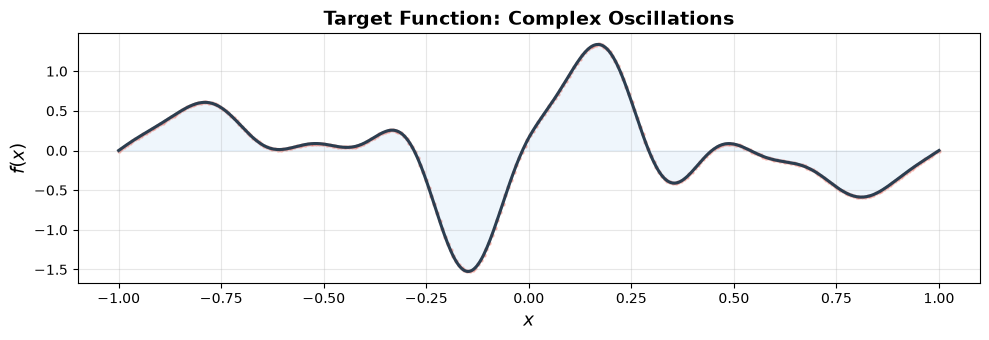

In [6]:
np.random.seed(42)

def complex_target(x):
    return (np.sin(4 * np.pi * x) * np.exp(-x**2 / 0.3) +
            0.3 * np.cos(8 * np.pi * x + 1.0) * (1 - np.abs(x)) +
            0.5 * np.sin(2 * np.pi * x))

X_train = np.linspace(-1, 1, 300).reshape(-1, 1)
y_train = complex_target(X_train).ravel()

fig, ax = plt.subplots(figsize=(10, 3.5))
X_plot = np.linspace(-1, 1, 500)
ax.plot(X_plot, complex_target(X_plot), '#2C3E50', linewidth=2.2)
ax.fill_between(X_plot, complex_target(X_plot), alpha=0.08, color='#3498DB')
ax.scatter(X_train.ravel(), y_train, s=5, alpha=0.3, c='#E74C3C')
ax.set_xlabel('$x$', fontsize=13); ax.set_ylabel('$f(x)$', fontsize=13)
ax.set_title('Target Function: Complex Oscillations', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [7]:
class DeepNN:
    """K-layer NN with ReLU + Adam"""
    def __init__(self, layer_sizes, lr=0.005, epochs=15000):
        self.layer_sizes = layer_sizes; self.lr = lr; self.epochs = epochs
        self.loss_history = []

    def _init_params(self):
        self.W, self.b = [], []
        for i in range(len(self.layer_sizes)-1):
            di, do = self.layer_sizes[i], self.layer_sizes[i+1]
            self.W.append(np.random.randn(di, do)*np.sqrt(2.0/max(di,1)))
            self.b.append(np.zeros((1, do)))

    def _init_adam(self):
        self.mW=[np.zeros_like(w) for w in self.W]
        self.vW=[np.zeros_like(w) for w in self.W]
        self.mb=[np.zeros_like(b) for b in self.b]
        self.vb=[np.zeros_like(b) for b in self.b]

    def _forward(self, X):
        layers = []; a = X
        for i in range(len(self.W)-1):
            z = a @ self.W[i] + self.b[i]; a = relu(z)
            layers.append((z, a))
        z = a @ self.W[-1] + self.b[-1]
        layers.append((z, z)); return layers

    def fit(self, X, y):
        n = X.shape[0]; y = y.reshape(-1, 1)
        self._init_params(); self._init_adam()
        b1, b2, eps = 0.9, 0.999, 1e-8
        for epoch in range(self.epochs):
            layers = self._forward(X); yp = layers[-1][1]
            loss = np.mean((yp-y)**2); self.loss_history.append(loss)
            L = len(self.W); dL = (2.0/n)*(yp-y)
            for l in reversed(range(L)):
                ap = layers[l-1][1] if l>0 else X
                dW = ap.T @ dL; db = np.sum(dL, axis=0, keepdims=True)
                dL_nxt = None
                if l > 0:
                    dA = dL @ self.W[l].T
                    dL_nxt = dA * (layers[l-1][0] > 0).astype(float)
                t = epoch+1
                for param, grad, m, v in [(self.W[l],dW,self.mW[l],self.vW[l]),
                                           (self.b[l],db,self.mb[l],self.vb[l])]:
                    m[:]=b1*m+(1-b1)*grad; v[:]=b2*v+(1-b2)*grad**2
                    param -= self.lr*(m/(1-b1**t))/(np.sqrt(v/(1-b2**t))+eps)
                if l>0: dL = dL_nxt

    def predict(self, X):
        return self._forward(X)[-1][1].ravel()

def count_params(sizes):
    return sum(sizes[i]*sizes[i+1]+sizes[i+1] for i in range(len(sizes)-1))

configs = [
    ("Shallow Wide (1 layer, 30 units)", [1, 30, 1], '#E74C3C'),
    ("Deep Narrow (4 layers, 5 each)",   [1, 5, 5, 5, 5, 1], '#2980B9'),
]

results = {}
for name, arch, color in configs:
    np.random.seed(42)
    n_p = count_params(arch)
    print(f"Training: {name} - {n_p} params")
    model = DeepNN(layer_sizes=arch, lr=0.008, epochs=20000)
    model.fit(X_train, y_train)
    results[name] = {'model': model, 'params': n_p, 'color': color}
    print(f"  Final MSE: {model.loss_history[-1]:.6f}")

print("\\nTraining complete!")

Training: Shallow Wide (1 layer, 30 units) - 91 params
  Final MSE: 0.074661
Training: Deep Narrow (4 layers, 5 each) - 106 params
  Final MSE: 0.012941
\nTraining complete!


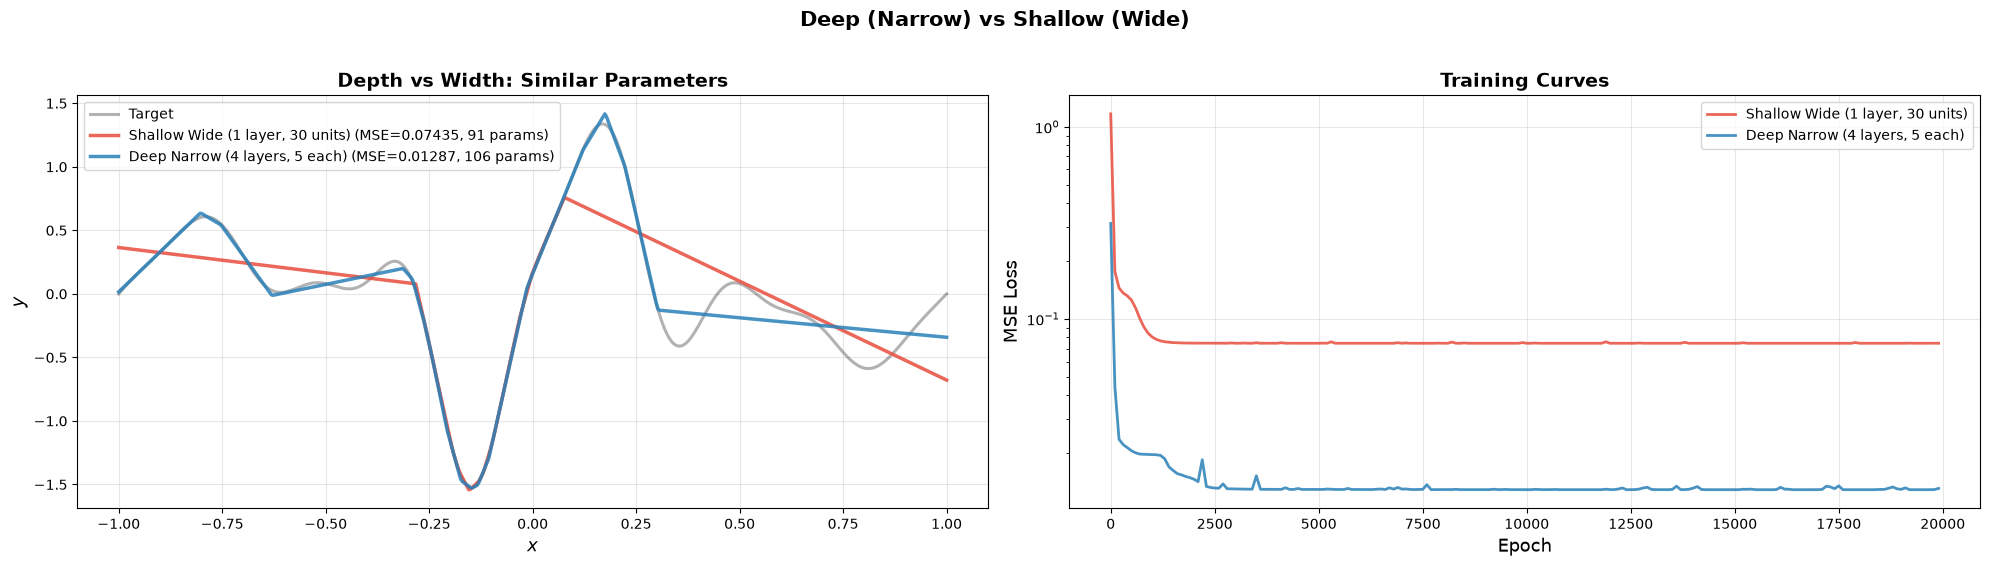

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5.5))
X_test = np.linspace(-1, 1, 500).reshape(-1, 1)
y_true = complex_target(X_test).ravel()

ax = axes[0]
ax.plot(X_test, y_true, 'k-', linewidth=2.2, alpha=0.3, label='Target')
for name, res in results.items():
    yp = res['model'].predict(X_test)
    mse = np.mean((yp-y_true)**2)
    ax.plot(X_test, yp, res['color'], linewidth=2.5, alpha=0.85,
            label=f"{name} (MSE={mse:.5f}, {res['params']} params)")
ax.set_xlabel('$x$', fontsize=13); ax.set_ylabel('$y$', fontsize=13)
ax.set_title('Depth vs Width: Similar Parameters', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
for name, res in results.items():
    losses = res['model'].loss_history
    steps = np.arange(0, len(losses), 100)
    ax.plot(steps, [losses[i] for i in steps], res['color'], linewidth=2,
            alpha=0.85, label=name)
ax.set_xlabel('Epoch', fontsize=13); ax.set_ylabel('MSE Loss', fontsize=13)
ax.set_title('Training Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.set_yscale('log'); ax.grid(True, alpha=0.3)

fig.suptitle('Deep (Narrow) vs Shallow (Wide)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 3.6 小结
